In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('brest cancer data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)
print(df.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0],test_size=0.2, random_state=2)
X_train.head()

(569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
560,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,0.1537,0.06171,...,15.30,33.17,100.20,706.7,0.1241,0.22640,0.1326,0.10480,0.2250,0.08321
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
198,19.18,22.49,127.50,1148.0,0.08523,0.14280,0.11140,0.06772,0.1767,0.05529,...,23.36,32.06,166.40,1688.0,0.1322,0.56010,0.3865,0.17080,0.3193,0.09221
203,13.81,23.75,91.56,597.8,0.13230,0.17680,0.15580,0.09176,0.2251,0.07421,...,19.20,41.85,128.50,1153.0,0.2226,0.52090,0.4646,0.20130,0.4432,0.10860
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,...,12.84,35.34,87.22,514.0,0.1909,0.26980,0.4023,0.14240,0.2964,0.09606


Lesser number of neighbors is better, but prone to overfitting, and vice versa.

**The maximum number of neighbors is the total number of features in the dataset, causing underfitting.**


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

accuracy_score(y_test, y_pred)

0.9035087719298246

There are two ways to find the required number of `K` in the dataset:
1. Heustric method
2. Experimentation method 


### 1. Heuristic Method (The Elbow Method)

The **Elbow Method** is a heuristic used to determine the optimal number of clusters by calculating the **Within-Cluster Sum of Squares (WCSS)** for different values of $K$.

*   **WCSS (Inertia):** Measures the sum of squared distances between each data point and its assigned cluster centroid.
*   **The "Elbow":** We plot $K$ against WCSS and look for the "elbow" point where the rate of decrease significantly slows down. This point represents the optimal balance between cluster compactness and the number of clusters.

- Bascially it is done by doing the `square root of number of features`, but make sure that you get any even number as the square root, then make it an odd number by either adding or subtracting 1. 

### 2. Experimentation Method (The Silhouette Method)

Bascially here you find the optimal number of clusters by experimenting on every number of clusters and then finding the one that has the highest accuracy score.

The **Silhouette Method** is used to validate the consistency within clusters of data. It provides a succinct graphical representation of how well each object has been classified.

*   **Silhouette Score:** The score ranges from -1 to +1. 
    *   **+1:** Indicates that the sample is far away from the neighboring clusters (well-clustered).
    *   **0:** Indicates that the sample is on or very close to the decision boundary between two neighboring clusters.
    *   **-1:** Indicates that those samples might have been assigned to the wrong cluster.

*   **The Calculation:** For a data point $i$, the silhouette coefficient $s(i)$ is defined as:
    $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
    *   $a(i)$: The average distance between $i$ and all other points in the same cluster (Cohesion).
    *   $b(i)$: The average distance between $i$ and all points in the nearest cluster that $i$ is not a part of (Separation).

*   **Optimal K:** We determine the optimal number of clusters by picking the $K$ that yields the maximum average silhouette score. Unlike the Elbow Method, which looks for a "bend," the Silhouette Method looks for the highest peak.

### Checking for accuracy on different clusters

In [30]:
scores = []
max_accuracy = 0

for i in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Calculate once and store
    current_accuracy = np.round(accuracy_score(y_test, y_pred), 2)
    scores.append(current_accuracy)

    # Update and print only if accuracy improves
    if current_accuracy > max_accuracy:
        max_accuracy = current_accuracy
        print(f"Neighbors: {i} | Accuracy: {current_accuracy}")

print(f"\n\nMax accuracy: {max(scores)} at index {scores.index(max(scores))}")

# as you can see the highest accuracy is at neighbours 7

Neighbors: 1 | Accuracy: 0.89
Neighbors: 3 | Accuracy: 0.9
Neighbors: 5 | Accuracy: 0.91
Neighbors: 6 | Accuracy: 0.92
Neighbors: 7 | Accuracy: 0.93


Max accuracy: 0.93 at index 6


In [31]:
scores

[np.float64(0.89),
 np.float64(0.89),
 np.float64(0.9),
 np.float64(0.89),
 np.float64(0.91),
 np.float64(0.92),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93),
 np.float64(0.93)]

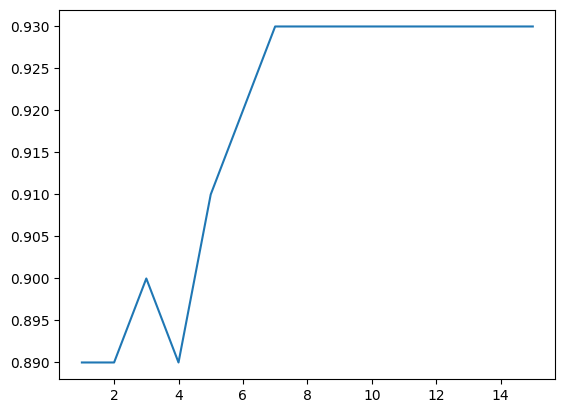

In [32]:
import matplotlib.pyplot as plt

plt.plot(range(1,16),scores)


### Limitations of K-Nearest Neighbors (KNN)

1. **Computational Complexity (Lazy Learning):**
   - KNN is a "lazy learner," meaning it performs no explicit training phase. All computation happens during prediction.
      - In simple words, in training phase it just stores the data points, and during prediction it calculates the distance between the new data point and all the stored data points.
      - The training might be fast, but the prediction will definitely be slow, if it is a very large data set.
   - Prediction time complexity is $O(n \cdot d)$, where $n$ is the number of samples and $d$ is the number of dimensions. This makes it extremely slow for large datasets.

2. **High Memory Usage:**
   - The algorithm must store the entire training dataset in memory to calculate distances for every new query point.

3. **Sensitivity to Feature Scaling:**
   - Since KNN relies on distance metrics (e.g., Euclidean distance), features with larger scales will disproportionately influence the results. Feature scaling (Standardization or Normalization) is strictly required.

4. **Curse of Dimensionality:**
   - In high-dimensional spaces, the distance between points becomes less meaningful as the volume of the space increases exponentially. This often leads to overfitting and degraded performance unless dimensionality reduction (e.g., PCA) is applied.

5. **Sensitivity to Noise and Outliers:**
   - A single outlier can significantly affect the prediction, especially when the value of $K$ is small.

6. **Imbalanced Data Bias:**
   - If one class has a significantly higher frequency than others, it will naturally dominate the "neighborhood" of most query points, leading to biased classifications towards the majority class.

7. **Optimal K Selection:**
   - Choosing the right value for $K$ is non-trivial. A small $K$ makes the model sensitive to noise (high variance), while a large $K$ makes the boundaries less distinct (high bias). Finding the balance requires exhaustive cross-validation.



# The Difference Between KNN and K-Means

Although both algorithms have a "**K**" in their name and rely on **distance calculations** (like Euclidean distance) to work, they are completely different algorithms used for entirely different purposes in Machine Learning.

The fundamental difference lies in their learning type: **KNN is for Supervised Learning**, while **K-Means is for Unsupervised Learning**.



### 1. KNN (K-Nearest Neighbors)
*   **Type:** Supervised Learning (Classification & Regression)
*   **Goal:** Predict the label (or value) of a **new, unknown data point** based on the data you already have.
*   **Intuition:** *"Tell me who your neighbors are, and I'll tell you who you are."*
*   **What does 'K' mean?:** $\mathbf{K}$ represents the **number of nearest data points (neighbors)** the algorithm looks at to make its decision.
    *   *Example:* If you want to predict if an email is "Spam" or "Not Spam," and you set $K=5$, the algorithm looks at the 5 emails that are mathematically "closest" to the new email. If 4 are Spam and 1 is Not Spam, the new email is classified as Spam (majority voting).
*   **Training:* KNN is often called a "lazy learner" because it technically doesn't "train" a model in advance; it just memorizes the dataset and does all the math at the exact moment a prediction is asked for.

### 2. K-Means (K-Means Clustering)
*   **Type:** Unsupervised Learning (Clustering)
*   **Goal:** Group **unlabeled data** into separate buckets (clusters) based on their similarities. There are no right or wrong answers (no target variable $y$).
*   **Intuition:** *"Find the center mass of similar items and pull them together into groups."*
*   **What does 'K' mean?:** $\mathbf{K}$ represents the **number of clusters (groups)** you want the algorithm to divide your entire dataset into.
    *   *Example:* You have a list of of 10,000 customers, but you don't know anything about their buying habits. You set $K=3$. The algorithm will mathematically group them into 3 distinct segments (e.g., it might naturally discover clusters for "Bargain Hunters," "Luxury Buyers," and "Occasional Shoppers").
*   **Training:* K-Means is an iterative algorithm. It randomly drops $K$ center points (centroids) into the data, assigns points to the nearest centroid, moves the centroid to the middle of those points, and repeats until the groups stop changing.



### Quick Comparison Table

| Feature | K-Nearest Neighbors (KNN) | K-Means Clustering |
| :--- | :--- | :--- |
| **Learning Type** | Supervised | Unsupervised |
| **Data Requirement** | Labeled Data (Needs both $X$ and $y$) | Unlabeled Data (Only needs $X$) |
| **Primary Objective** | Categorize or predict a value for new data | Discover hidden patterns and group existing data |
| **Meaning of 'K'** | Number of Nearest Neighbors | Number of Clusters/Groups |
| **Output Type** | A label (Class A, Class B) or a number | A cluster assignment (Group 1, Group 2) |
| **Algorithm Nature** | "Lazy" (Waits for a prediction request before computing) | Iterative (Computes centers until they stabilize) |



### Simple Analogy
*   **KNN Strategy:** You walk into a party and don't know what language to speak. You listen to the **3 people closest to you** ($K=3$) and hear they are speaking Spanish. You decide to speak Spanish too.
*   **K-Means Strategy:** You have a massive pile of assorted, unsorted LEGOs on the floor. You decide you want to organize them into **4 separate boxes** ($K=4$). You let the algorithm sort them based on similarities (it might end up grouping them by Color, Shape, or Size).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()

cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y));